In [1]:
import numpy as np 
import math
import matplotlib.pyplot as plt 

import I_functions_class as Inp
from astropy.io import fits
import module1 as m1
import numpy.linalg as linalg

import scipy 

from scipy.fft import fft, ifft
from scipy.fft import fftfreq

In [2]:
mu = 9.0968024e-24  
nu = 1.#in grams 
lam = 1.
GC = 1.
M = 1.e21
c = 1.
tol = 1.e-10

#r_initial = 2000.*M
r_final= -70.*M

r_final = 2*M

T = 1/(8*np.pi*M)
k = -10.
h = np.linspace(.01*T,20.*T,2000)


In [3]:
pauli_1 = [[0,1],[1,0]]
pauli_2 = [[0,complex(0,-1)],[complex(0,1),0]]
pauli_3 = [[1,0],[0,-1]]
Beta = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],[0,0,0,-1]])

In [4]:
gamma1 = np.array([[0,0,0,1],[0,0,1,0],[0,1,0,0],[1,0,0,0]])
gamma2 = np.array([[0,0,0,complex(0,-1)],[0,0,complex(0,1),0],[0,complex(0,-1),0,0],[complex(0,1),0,0,0]])
gamma3 = np.array([[0,0,1.,0],[0,0,0,-1.],[1.,0,0,0],[0,-1.,0,0]])

In [5]:
epsilon_x = 1
epsilon_y = 1
epsilon_z = 1

In [6]:
nx,ny,nz = 51, 51, 51
dx = epsilon_x
dy = epsilon_y
dz = epsilon_z

kx = np.linspace(-np.pi/dx,np.pi/dx, num=nx, axis=0)
ky = np.linspace(-np.pi/dy,np.pi/dy, num=ny, axis=0)
kz = np.linspace(-np.pi/dz,np.pi/dz, num=nz, axis=0)
W_k_flat = np.zeros((nx,ny,nz,4,4),dtype = complex)
W_k_flat_no_wilson = np.zeros((nx,ny,nz,4,4),dtype = complex)

for x in range(nx):
    for y in range(ny):
        for z in range(nz):
           W_k_flat[x,y,z,:,:] = np.dot(Beta,((mu + 1/epsilon_x + 1/epsilon_y + 1/epsilon_z)*np.identity(4) + (gamma1-2*np.identity(4))*np.exp(complex(0,kx[x]*epsilon_x))/(2*epsilon_x)+ (gamma2-2*np.identity(4))*np.exp(complex(0,ky[y]*epsilon_y))/(2*epsilon_y)+ (gamma3-2*np.identity(4))*np.exp(complex(0,kz[z]*epsilon_z))/(2*epsilon_z) - (gamma1+2*np.identity(4))*np.exp(complex(0,-kx[x]*epsilon_x))/(2*epsilon_x)- (gamma2+2*np.identity(4))*np.exp(complex(0,-ky[y]*epsilon_y))/(2*epsilon_y)- (gamma3+2*np.identity(4))*np.exp(complex(0,-kz[z]*epsilon_z))/(2*epsilon_z)))
           W_k_flat_no_wilson[x,y,z,:,:] = np.dot(Beta,((mu)*np.identity(4) + (gamma1)*np.exp(complex(0,kx[x]*epsilon_x))/(2*epsilon_x)+ (gamma2)*np.exp(complex(0,ky[y]*epsilon_y))/(2*epsilon_y)+ (gamma3)*np.exp(complex(0,kz[z]*epsilon_z))/(2*epsilon_z) - (gamma1)*np.exp(complex(0,-kx[x]*epsilon_x))/(2*epsilon_x)- (gamma2)*np.exp(complex(0,-ky[y]*epsilon_y))/(2*epsilon_y)- (gamma3)*np.exp(complex(0,-kz[z]*epsilon_z))/(2*epsilon_z)))
        



In [7]:
np.array(W_k_flat[1,2,0,:,:])

array([[ 8.92139572-3.91979531e-17j,  0.        +0.00000000e+00j,
         0.        -1.22464680e-16j, -0.24868989-1.25333234e-01j],
       [ 0.        +0.00000000e+00j,  8.92139572-3.91979531e-17j,
         0.24868989-1.25333234e-01j,  0.        +1.22464680e-16j],
       [ 0.        +1.22464680e-16j,  0.24868989+1.25333234e-01j,
        -8.92139572+3.91979531e-17j,  0.        +0.00000000e+00j],
       [-0.24868989+1.25333234e-01j,  0.        -1.22464680e-16j,
         0.        +0.00000000e+00j, -8.92139572+3.91979531e-17j]])

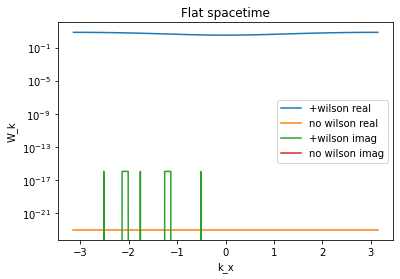

In [8]:
plt.plot(kx,np.real(W_k_flat[:,0,11,1,1]),label ='+wilson real ')
plt.plot(kx,np.real(W_k_flat_no_wilson[:,0,11,1,1]),label='no wilson real')
plt.plot(kx,np.imag(W_k_flat[:,0,11,1,1]),label ='+wilson imag ')
plt.plot(kx,np.imag(W_k_flat_no_wilson[:,0,11,1,1]),label='no wilson imag')
plt.title('Flat spacetime')
plt.xlabel('k_x')
plt.ylabel('W_k')           
plt.yscale('log')
plt.legend()
plt.show()

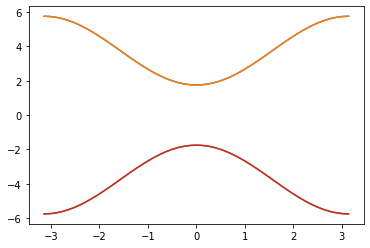

In [9]:
plt.plot(kx,np.real(W_k_flat[:,11,11,0,0]))
plt.plot(kx,np.real(W_k_flat[:,11,11,1,1]))
plt.plot(kx,np.real(W_k_flat[:,11,11,2,2]))
plt.plot(kx,np.real(W_k_flat[:,11,11,3,3]))

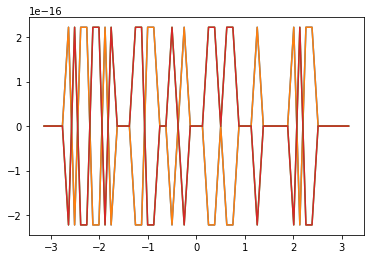

In [10]:
plt.plot(kx,np.imag(W_k_flat[:,11,11,0,0]))
plt.plot(kx,np.imag(W_k_flat[:,11,11,1,1]))
plt.plot(kx,np.imag(W_k_flat[:,11,11,2,2]))
plt.plot(kx,np.imag(W_k_flat[:,11,11,3,3]))

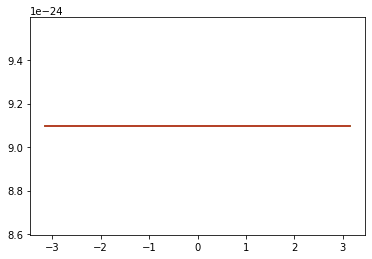

In [11]:
plt.plot(kx,np.abs(W_k_flat_no_wilson[:,11,11,0,0]))
plt.plot(kx,np.abs(W_k_flat_no_wilson[:,11,11,1,1]))
plt.plot(kx,np.abs(W_k_flat_no_wilson[:,11,11,2,2]))
plt.plot(kx,np.abs(W_k_flat_no_wilson[:,11,11,3,3]))

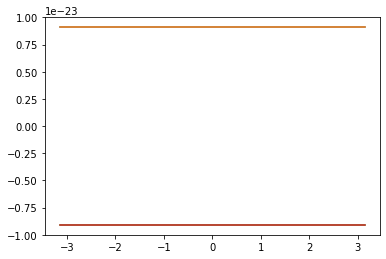

In [12]:
plt.plot(kx,np.real(W_k_flat_no_wilson[:,11,11,0,0]))
plt.plot(kx,np.real(W_k_flat_no_wilson[:,11,11,1,1]))
plt.plot(kx,np.real(W_k_flat_no_wilson[:,11,11,2,2]))
plt.plot(kx,np.real(W_k_flat_no_wilson[:,11,11,3,3]))

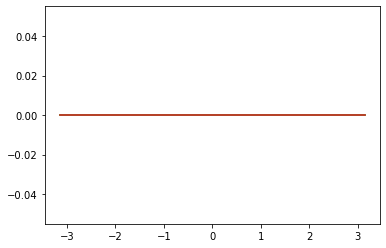

In [13]:
plt.plot(kx,np.imag(W_k_flat_no_wilson[:,11,11,0,0]))
plt.plot(kx,np.imag(W_k_flat_no_wilson[:,11,11,1,1]))
plt.plot(kx,np.imag(W_k_flat_no_wilson[:,11,11,2,2]))
plt.plot(kx,np.imag(W_k_flat_no_wilson[:,11,11,3,3]))

In [14]:
#think about diag slices in this format

In [136]:
nr,ntheta,nphi = 30, 10, 11
theta_points_mercator = np.linspace(0.00001,np.pi,ntheta)

theta_points = np.arctan(np.sinh(theta_points_mercator))

#k_thetas = 2*np.pi/theta_points


In [16]:
Beta,gamma1

(array([[ 1,  0,  0,  0],
        [ 0,  1,  0,  0],
        [ 0,  0, -1,  0],
        [ 0,  0,  0, -1]]),
 array([[0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0]]))

In [17]:
def sqrt_neg_g(r,theta):
    return (1-2*M/r )*r**2 * np.sin(theta)

def enu(r):
    return (1-2*M/r)

$H_{\rm Dirac} = \int dr_\star\, d\theta \,d\phi \,\overline{\xi}(x) \Bigl[ \tilde{\boldsymbol\gamma}^1 \partial_{r_{\star}} + \tilde{\boldsymbol\gamma}^2\frac{e^{\nu/2}}{r} \partial_\theta + \tilde{\boldsymbol\gamma}^3\frac{e^{\nu/2}}{r \sin\theta} \partial_\phi + \mu e^{\nu/2} \Bigr] \xi(x).$

In [18]:
%%time
###This cell has arrays listed as W but these map to M in the paper! 
m=1
r_points = np.linspace(-70*M,2000*M,nr) #in rstar 
tol =1.e-10
rs =  np.array([m1.r_star_to_r(x,M,tol) for x in r_points])

#krs = 2*np.pi/rs
#the tilde versions of gamma are the same as the flat spacetime, so all this is kinda wrong. 
#still have some geometric pieces but the derivative bits itself is pretty straightforward 


#these are single phi picked out 
#W_k_curved = np.zeros((nr,ntheta,4,4),dtype = complex)


W_k_curved_no_wilson = np.zeros((nr,ntheta,4,4),dtype = complex)

#W_k_curved_no_wilson has indices of [kr,ktheta,kphi,dirac a, diracb]

W_k_curved_wilson_only = np.zeros((nr,ntheta,4,4),dtype = complex)
W_k_curved_wilson_only2 = np.zeros((nr,ntheta,4,4),dtype = complex)
#HUGE NOTE: w wilson has no phi bit put in yet 

#below FT in phi as well 
phis = np.linspace(0.0000001,2*np.pi,nphi)
k_phis = 2*np.pi/phis
total_delta_phi = 2*(phis[1]-phis[0])
delta_phi_plus = phis[1]-phis[0]

Gamma_r=0


for r in range(1,nr-1):
    print(r)
    e_nuover2 = np.sqrt(1-2*M/rs[r])
    e_nuover2_min = np.sqrt(1-2*M/rs[r-1])
    e_nuover2_plus = np.sqrt(1-2*M/rs[r+1])
    #print(e_nuover2)
    
    delta_r_plus = rs[r+1]-rs[r]
    print(delta_r_plus)
    delta_rstar_plus = r_points[r+1]-r_points[r]
    delta_r_minus = rs[r]-rs[r-1]
    total_delta_r = delta_r_plus+delta_r_minus
    total_delta_rstar = r_points[2]-r_points[0]
    r_link = (rs[r+1]+rs[r])/2
    grr_link = 1/(1-2*M/r_link)

    r_link_min = (rs[r]+rs[r-1])/2
    grr_link_min = 1/(1-2*M/r_link_min)
    
    gthetatheta_link = 1/rs[r]**2
    
    Gamma_theta =.5* enu(rs[r])**.5 *np.dot(gamma1,gamma2)
    
    for theta in range(1,ntheta-1):
        gphiphi_link = rs[r]**2 *np.sin(theta_points[theta])**2
        epsilon_theta_plus = (theta_points[theta+1]-theta_points[theta])
        epsilon_theta_minus = (theta_points[theta]-theta_points[theta-1])
        total_delta_theta = epsilon_theta_plus+epsilon_theta_minus
        theta_link = (theta_points[theta+1]+theta_points[theta])/2
        Gamma_phi = .5* (np.sin(theta_points[theta])*np.dot(gamma1,gamma2)*(1-2*self.M/r)**.5  + np.cos(theta_points[theta])*np.dot(gamma2,gamma3))
        Vcell_curved_link = epsilon_theta_plus* delta_phi_plus * (r_points[1]-r_points[0])
        
        
        #curved_coefficient = Vcell_curved_link*( sqrt_neg_g(r_link,theta_points[theta])*np.sqrt(grr_link)/delta_rstar_plus   +  sqrt_neg_g(rs[r],theta_link)*np.sqrt(gthetatheta_link) / epsilon_theta_plus)

        W_k_curved_no_wilson[r,theta,:,:] += np.dot(Beta,e_nuover2*(mu+(gamma3)*np.exp(complex(0,2*np.pi*m/nphi))/(total_delta_phi*rs[r]*np.sin(theta_points[theta]))- (gamma3)*np.exp(complex(0,-2*np.pi*m/nphi))/(total_delta_phi*rs[r]*np.sin(theta_points[theta])))) 
        W_k_curved_no_wilson[r+1,theta,:,:] += np.dot(Beta,gamma1/(total_delta_rstar))
        #print((total_delta_phi*rs[r]*np.sin(theta_pointstheta])))  #does it make sense for this to be 0? 
        W_k_curved_no_wilson[r-1,theta,:,:] += -np.dot(Beta,gamma1/(total_delta_rstar))
        W_k_curved_no_wilson[r,theta+1,:,:] += np.dot(Beta,e_nuover2*gamma2/(total_delta_theta*rs[r]))
        W_k_curved_no_wilson[r,theta-1,:,:] += -np.dot(Beta,e_nuover2*gamma2/(total_delta_theta*rs[r]))

        #ignoring phi for now. this would be a FT in phi and contribute only to diagonal pieces    
        wilson_coeff = Beta*Vcell_curved_link*(delta_r_plus*sqrt_neg_g(rs[r],theta_points[theta]))
        wilson_coeff_theta = Beta*Vcell_curved_link*(epsilon_theta_plus*sqrt_neg_g(rs[r],theta_points[theta]))
        
        #print(wilson_coeff)
        #diagonal from +epsilon r terms (eq 52) 
        W_k_curved_wilson_only[r,theta,:,:] += np.dot(wilson_coeff, grr_link**.5 * (1/(delta_r_plus**2 / Vcell_curved_link /rs[r]**2/np.sin(theta_points[theta])/e_nuover2)))
        #daignal from -epsilon r terms 
        W_k_curved_wilson_only[r,theta,:,:] += np.dot(wilson_coeff, grr_link_min**.5 * (1/(delta_r_minus**2 / Vcell_curved_link /rs[r]**2/np.sin(theta_points[theta])/e_nuover2_min)))
        #diagonal from +epsilon theta terms (eq 52) 
        W_k_curved_wilson_only[r,theta,:,:] += np.dot(wilson_coeff_theta, gthetatheta_link**.5 * (1/(epsilon_theta_plus**2 / Vcell_curved_link /rs[r]**2/np.sin(theta_points[theta])/e_nuover2)))
        #daignal from -epsilon theta terms 
        W_k_curved_wilson_only[r,theta,:,:] += np.dot(wilson_coeff_theta, gthetatheta_link**.5 * (1/(epsilon_theta_minus**2 / Vcell_curved_link /rs[r]**2/np.sin(theta_points[theta-1])/e_nuover2)))
                                                                     
        #turn to eq 53 and 54         
        #r+1
        W_k_curved_wilson_only2[r+1,theta,:,:] += -np.dot(wilson_coeff ,(1/delta_r_plus**2)*np.exp(-delta_r_plus*Gamma_r)*(Vcell_curved_link*rs[r+1]**2*np.sin(theta_points[theta])*e_nuover2_plus)**-.5 *(Vcell_curved_link*rs[r]**2*np.sin(theta_points[theta])*e_nuover2)**-.5)
        #r-1
        W_k_curved_wilson_only2[r-1,theta,:,:] += -np.dot(wilson_coeff ,(1/delta_r_minus**2)*np.exp(delta_r_minus*Gamma_r)*(Vcell_curved_link*rs[r]**2*np.sin(theta_points[theta])*e_nuover2)**-.5 *(Vcell_curved_link*rs[r-1]**2*np.sin(theta_points[theta])*e_nuover2_min)**-.5)
        #theta+1
        W_k_curved_wilson_only2[r,theta+1,:,:] += -np.dot(wilson_coeff_theta ,(1/epsilon_theta_plus**2)*np.exp(-epsilon_theta_plus*Gamma_theta)*(Vcell_curved_link*rs[r]**2*np.sin(theta_points[theta+1])*e_nuover2)**-.5 *(Vcell_curved_link*rs[r]**2*np.sin(theta_points[theta])*e_nuover2)**-.5)
        #theta-1
        W_k_curved_wilson_only2[r,theta-1,:,:] += -np.dot(wilson_coeff_theta ,(1/epsilon_theta_minus**2)*np.exp(epsilon_theta_minus*Gamma_theta)*(Vcell_curved_link*rs[r]**2*np.sin(theta_points[theta])*e_nuover2)**-.5 *(Vcell_curved_link*rs[r]**2*np.sin(theta_points[theta-1])*e_nuover2)**-.5)
        
        
        #now come back to phi! 
        
        """ OLD METHOD I THINK BAD 
        for m in range(len(phis)):
            
            
            W_k_curved_no_wilson[r,theta,m,:,:] = Beta*e_nuover2*(mu+(gamma3)*np.exp(complex(0,2*np.pi*m/nphi))/(total_delta_phi*rs[r]*np.sin(theta_points[theta]))- (gamma3)*np.exp(complex(0,-2*np.pi*m/nphi))/(total_delta_phi*rs[r]*np.sin(theta_points[theta])))
            W_k_curved_no_wilson[r+1,theta,m,:,:] = Beta*gamma1/(total_delta_rstar)
            W_k_curved_no_wilson[r-1,theta,m,:,:] = -Beta*gamma1/(total_delta_rstar)
            W_k_curved_no_wilson[r,theta+1,m,:,:] = Beta*e_nuover2*gamma2/(total_delta_theta*rs[r])
            W_k_curved_no_wilson[r,theta-1,m,:,:] = -Beta*e_nuover2*gamma2/(total_delta_theta*rs[r])
            #( sqrt_neg_g(r_link,theta_points[theta])*np.sqrt(grr_link)/delta_rstar_plus   +  sqrt_neg_g(rs[r],theta_link)*np.sqrt(gthetatheta_link) / epsilon_theta_plus)

            #diagonal wilson 
            #W_k_curved_wilson_only[r,theta,m,:,:] = Beta*Vcell_curved_link* ( sqrt_neg_g(r_link,theta_points[theta])*np.sqrt(grr_link) * (enu(rs[r+1])**1/2 /rs[r+1]**2 +enu(rs[r])**1/2 /rs[r]**2)/np.sin(theta_points[theta])/(epsilon_theta_plus* delta_phi_plus * (r_points[1]-r_points[0])) /delta_rstar_plus   +  sqrt_neg_g(rs[r],theta_link)*np.sqrt(gthetatheta_link)*(enu(rs[r])**1/2 /rs[r]**2)*(1/np.sin(theta_points[theta+1])/((theta_points[theta+2]+theta_points[theta+1])/2 - (theta_points[theta+1]+theta_points[theta] )/2) + 1/np.sin(theta_points[theta])/((theta_points[theta+1]+theta_points[theta])/2 + (theta_points[theta]+theta_points[theta-1] )/2))/(delta_phi_plus * (r_points[1]-r_points[0])) /epsilon_theta_plus)
            #phi diagonal + offdiagonal in m basis, FT
            #W_k_curved_wilson_only[r,theta,m,:,:] = Beta*Vcell_curved_link*sqrt_neg_g(rs[r],theta_points[theta])*np.sqrt(gphiphi_link)*2*enu(rs[r])**1/2/(delta_phi_plus*delta_r_plus*epsilon_theta_plus*rs[r]*np.sin(theta_points[theta])) *(2 + np.exp(complex(0,2*np.pi*m/nphi)*np.exp(-epsilon_phi_plus*Gamma_phi) + np.exp(complex(0,-2*np.pi*m/nphi)*np.exp(epsilon_phi_plus*Gamma_phi) 
            #plus r
            #W_k_curved_wilson_only[r+1,theta,m,:,:] = Beta*Vcell_curved_link* ( sqrt_neg_g(r_link,theta_points[theta])*np.sqrt(grr_link))* np.exp(-delta_rstar_plus*Gamma_rstar) * (enu(rs[r+1])**1/4 /rs[r+1])*(enu(rs[r])**1/4 /rs[r])/np.sin(theta_points[theta])/(epsilon_theta_plus* delta_phi_plus *(r_points[1]-r_points[0])) /delta_rstar_plus
            #minus r
            #W_k_curved_wilson_only[r-1,theta,m,:,:] = Beta*Vcell_curved_link* ( sqrt_neg_g(r_link,theta_points[theta])*np.sqrt(grr_link))* np.exp(delta_rstar_plus*Gamma_rstar) * (enu(rs[r+1])**1/4 /rs[r+1])*(enu(rs[r])**1/4 /rs[r])/np.sin(theta_points[theta])/(epsilon_theta_plus* delta_phi_plus *(r_points[1]-r_points[0])) /delta_rstar_plus
            #plus theta 
            #W_k_curved_wilson_only[r,theta+1,m,:,:] = Beta*Vcell_curved_link* (sqrt_neg_g(rs[r],theta_link)*np.sqrt(gthetatheta_link))* np.exp(-epsilon_theta_plus*Gamma_theta)*(enu(rs[r])**1/2 /rs[r]**2)* (1/np.sqrt(np.sin(theta_points[theta+1]))/np.sqrt((theta_points[theta+2]+theta_points[theta+1])/2 - (theta_points[theta+1]+theta_points[theta] )/2))*(1/np.sin(theta_points[theta])/np.sqrt((theta_points[theta+1]+theta_points[theta])/2 + (theta_points[theta]+theta_points[theta-1] )/2))/(delta_phi_plus * (r_points[1]-r_points[0])) /epsilon_theta_plus
            #minus theta
            #W_k_curved_wilson_only[r,theta-1,m,:,:] = Beta*Vcell_curved_link* (sqrt_neg_g(rs[r],theta_link)*np.sqrt(gthetatheta_link))* np.exp(-epsilon_theta_plus*Gamma_theta)*(enu(rs[r])**1/2 /rs[r]**2)* (1/np.sqrt(np.sin(theta_points[theta+1]))/np.sqrt((theta_points[theta+2]+theta_points[theta+1])/2 - (theta_points[theta+1]+theta_points[theta] )/2))*(1/np.sin(theta_points[theta])/np.sqrt((theta_points[theta+1]+theta_points[theta])/2 + (theta_points[theta]+theta_points[theta-1] )/2))/(delta_phi_plus * (r_points[1]-r_points[0])) /epsilon_theta_plus
                        
        """    

1
6.290849106293332e+22


NameError: name 'self' is not defined

In [19]:
W_k_curved_no_wilson[1,1,0,0],W_k_curved_no_wilson[1,1,1,1],W_k_curved_no_wilson[1,1,2,2],W_k_curved_no_wilson[1,1,3,3]

(0j, 0j, 0j, 0j)

In [20]:
W_k_curved_wilson_only[1,1,0,0],W_k_curved_wilson_only[1,1,1,1],W_k_curved_wilson_only[1,1,2,2],W_k_curved_wilson_only[1,1,3,3]

(0j, 0j, 0j, 0j)

/tmp/ipykernel_522022/3622774269.py:6: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


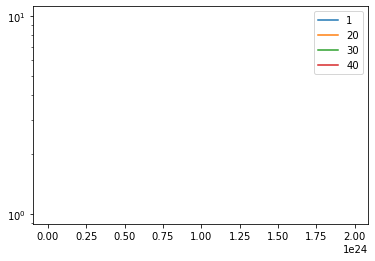

In [21]:
plt.plot(rs,np.abs(W_k_curved_no_wilson[:,1,0,0]),label = '1')
plt.plot(rs,np.abs(W_k_curved_no_wilson[:,20,1,1]),label ='20')
plt.plot(rs,np.abs(W_k_curved_no_wilson[:,30,2,2]),label='30')
plt.plot(rs,np.abs(W_k_curved_no_wilson[:,40,3,3]),label='40')
plt.legend()
plt.yscale('log')
plt.show()

/tmp/ipykernel_522022/1306143822.py:5: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


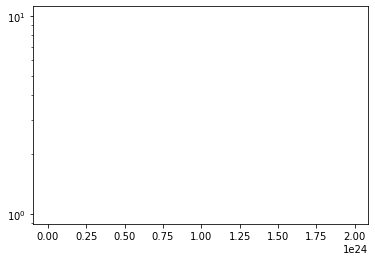

In [22]:
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,24,0,0]))
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,34,0,0]))
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,44,0,0]))
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,54,0,0]))
plt.yscale('log')
plt.show()

/tmp/ipykernel_522022/519705846.py:5: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


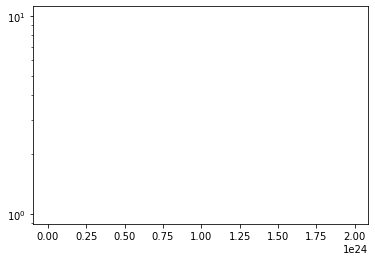

In [23]:
plt.plot(rs,np.abs(W_k_curved_wilson_only2[:,24,0,0]))
plt.plot(rs,np.abs(W_k_curved_wilson_only2[:,34,0,0]))
plt.plot(rs,np.abs(W_k_curved_wilson_only2[:,44,0,0]))
plt.plot(rs,np.abs(W_k_curved_wilson_only2[:,54,0,0]))
plt.yscale('log')
#plt.ylim(1e25,1e28)
plt.show()

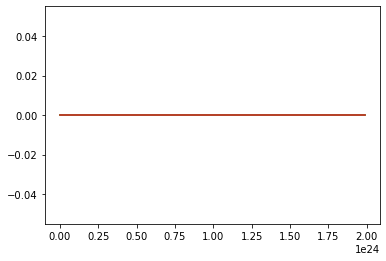

In [24]:
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,24,0,0])+np.abs(W_k_curved_no_wilson[:,24,0,0] ))
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,24,1,1])+np.abs(W_k_curved_no_wilson[:,24,1,1] ))
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,24,2,2])+np.abs(W_k_curved_no_wilson[:,24,2,2] ))
plt.plot(rs,np.abs(W_k_curved_wilson_only[:,24,3,3])+np.abs(W_k_curved_no_wilson[:,24,3,3] ))


In [154]:
###lowkey ignore everything before this!!!!!



#### most of the work is under here

In [40]:
class Minkowski(): 
    def __init__(self,gxx,gyy,gzz):
        self.gxx = gxx 
        self.gyy = gyy 
        self.gzz = gzz
        self.gamma1 = np.array([[0,0,0,1],[0,0,1,0],[0,1,0,0],[1,0,0,0]])
        self.gamma2 = np.array([[0,0,0,complex(0,-1)],[0,0,complex(0,1),0],[0,complex(0,-1),0,0],[complex(0,1),0,0,0]])
        self.gamma3 = np.array([[0,0,1.,0],[0,0,0,-1.],[1.,0,0,0],[0,-1.,0,0]])
    def get_e_nu(self,x):
        return 1
    def get_g11(self,x):
        return self.gxx
    def get_g22(self,x):
        return self.gyy
    def get_g33(self,x,y):
        return self.gzz
    def sqrt_neg_g(self,x,y) :
        return 1
    def Gamma1(self):
        return 0
    def Gamma2(self,x):
        return 0
    def Gamma3(self,x,y):
        return 0 #check these

class Schwarzschild():
    def __init__(self,M):
        self.M = M 
        self.tol = 1.e-10
        self.gamma1 = np.array([[0,0,0,1],[0,0,1,0],[0,1,0,0],[1,0,0,0]])
        self.gamma2 = np.array([[0,0,0,complex(0,-1)],[0,0,complex(0,1),0],[0,complex(0,-1),0,0],[complex(0,1),0,0,0]])
        self.gamma3 = np.array([[0,0,1.,0],[0,0,0,-1.],[1.,0,0,0],[0,-1.,0,0]])
    
    def get_M(self,M):
        return self.M
    def get_e_nu(self,rstar):
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        return 1-2*self.M/r
    def get_g11(self,rstar): #rstarrstar would be reciprocal of this 
        #print(rstar)
        #print(self.tol,self.M)
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        return (1-2*M/r)   #fixed #this is a downstairs index 
    def get_g22(self, rstar): #thetatheta
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        return r**2 
    def get_g33(self, rstar,theta): #phiphi 
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        return r**2 *np.sin(theta)**2 
    def sqrt_neg_g(self,rstar,theta):
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        #print((1-2*self.M/r))
        return (1-2*self.M/r) *r**2 *np.sin(theta)    #put this 
    def Gamma1(self):
        return 0
    def Gamma2(self,rstar):
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        return .5* (1-2*self.M/r)**.5 *np.dot(self.gamma1,self.gamma2)
    def Gamma3(self,rstar,theta):
        r = m1.r_star_to_r(rstar,self.M,self.tol)
        return .5*(np.sin(theta)*np.dot(self.gamma1,self.gamma2)*(1-2*self.M/r)**.5 + np.cos(theta)*np.dot(self.gamma2,self.gamma3))
    


In [153]:
def generate_M_matrices(spacetime,coord1_array, coord2_array, coord3_array,r_wilson, M=None,gxx=None,gyy=None,gzz=None): 
    if spacetime == 'Minkowski': 
        print('flat')
        G = np.zeros(len(coord1_array))
        G.fill(1)
        bg = Minkowski(gxx,gyy,gzz)
        #implies coord 1 = x, coord2 = y, coord3= z
    elif spacetime == 'Schwarzschild':
        print('curved')
        G = np.zeros(len(coord1_array))
        G.fill(1)
        G[-10:] = np.linspace(1,1e-5,10)  #
        coord1_array = coord1_array/G
        bg = Schwarzschild(M)#*G) #ok does this make sense. i think i am making mu big later. 
        
        #implies coord 1 = r_star, coord2 = theta, coord3= phi
    else: 
        print ('fix spacetime')
        return 
    #mu = 9.0968024e-24  #electron mass 
    #G = units of length squared 
    
    mu =  9.0968024e-24/ G #change this to be dynamic in r... 
    Beta = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],[0,0,0,-1]])
    
    M_dirac = np.zeros((len(coord1_array),len(coord2_array),len(coord3_array),4,4),dtype=complex)
    M_wilson = np.zeros((len(coord1_array),len(coord2_array),len(coord3_array),4,4),dtype = complex)
    c1_len = len(coord1_array)-1
    c2_len = len(coord2_array)-1
    c3_len = len(coord3_array)-1

    #r and rstar discrepancy 
    spacing1 = coord1_array[1:]-coord1_array[:-1]  
    spacing2 = coord2_array[1:]-coord2_array[:-1]
    spacing3 = coord3_array[1:]-coord3_array[:-1]

    #print(spacing1)
    for c1 in range(2,len(coord1_array)-3,1): #need to think about 
        #print(c1)
        #make sure the boundary conditions have 
        for c2 in range(0,len(coord2_array)-1,1):
            for c3 in range(0,len(coord3_array)-1,1):  
                bg.get_g11(coord1_array[c1])**.5
                
                #diagonal                 4x4           numbers 
                M_dirac[c1,c2,c3,:,:] += np.dot(np.identity(4),mu[c1]*np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5)))
                #c1                       4x4       numbers
                M_dirac[c1+1,c2,c3,:,:] += np.dot(bg.gamma1,np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5))/((bg.get_g11(coord1_array[c1]))**.5) /spacing1[c1])
                M_dirac[c1-1,c2,c3,:,:] += -np.dot(bg.gamma1,np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5))/((bg.get_g11(coord1_array[c1]))**.5)/spacing1[c1])
                #c2                       4x4       numbers
                M_dirac[c1,(c2+1)%c2_len,c3,:,:] += np.dot(bg.gamma2,np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5))/((bg.get_g22(coord1_array[c1]))**.5) /spacing2[c2])
                M_dirac[c1,(c2-1)%c2_len,c3,:,:] += -np.dot(bg.gamma2,np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5))/((bg.get_g22(coord1_array[c1]))**.5)/spacing2[c2])
                #c3                       4x4       numbers
                M_dirac[c1,c2,(c3+1)%c3_len,:,:] += np.dot(bg.gamma3,np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5))/((bg.get_g33(coord1_array[c1],coord2_array[c2]))**.5) /spacing3[c3])
                M_dirac[c1,c2,(c3-1)%c3_len,:,:] += -np.dot(bg.gamma3,np.exp(np.sqrt(bg.get_e_nu(coord1_array[c1])**.5))/((bg.get_g33(coord1_array[c1],coord2_array[c2]))**.5)/spacing3[c3])
                
                #diagonal 
                #cell_info: 
                v_cell_c1_linkp = spacing1[c1+1]*spacing2[c2]*spacing3[c3]
                v_cell_c1_linkm = spacing1[c1-1]*spacing2[c2]*spacing3[c3]
                v_cell_c2_linkp = spacing1[c1]*spacing2[(c2+1)%c2_len]*spacing3[c3]
                v_cell_c2_linkm = spacing1[c1]*spacing2[(c2-1)%c2_len]*spacing3[c3]
                v_cell_c3_linkp = spacing1[c1]*spacing2[c2]*spacing3[(c3+1)%c3_len]
                v_cell_c3_linkm = spacing1[c1]*spacing2[c2]*spacing3[(c3-1)%c3_len]

                v_cell_c1_sitep = .5*(spacing1[c1+1]+spacing1[c1+2])*spacing2[c2]*spacing3[c3]
                v_cell_c1_site = .5*(spacing1[c1-1]+spacing1[c1])*spacing2[c2]*spacing3[c3]
                v_cell_c1_sitem = .5*(spacing1[c1-1]+spacing1[c1-2])*spacing2[c2]*spacing3[c3]
                
                v_cell_c2_sitep = .5*(spacing2[(c2+1)%c2_len]+spacing2[(c2+2)%c2_len])*spacing1[c1]*spacing3[c3]
                v_cell_c2_site = .5*(spacing2[(c2-1)%c2_len]+spacing2[c2])*spacing1[c1]*spacing3[c3]
                v_cell_c2_sitem = .5*(spacing2[(c2-1)%c2_len]+spacing2[(c2-2)%c2_len])*spacing1[c1]*spacing3[c3]
                
                v_cell_c3_sitep = .5*(spacing3[(c3+1)%c3_len]+spacing3[(c3+2)%c3_len])*spacing1[c1]*spacing2[c2]
                v_cell_c3_site = .5*(spacing3[(c3-1)%c3_len]+spacing3[c3])*spacing1[c1]*spacing2[c2]
                v_cell_c3_sitem = .5*(spacing3[(c3-1)%c3_len]+spacing3[(c3-2)%c3_len])*spacing1[c1]*spacing2[c2]

               
                
                """print('sqrt neg g')
                print(bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2]))
                print('vcell')
                print(v_cell_c1_linkp)     
                print('g11^.5')
                print(bg.get_g11(coord1_array[c1])**.5)"""

                
                #print('total')
                #print((bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*spacing1[c1]*v_cell_c1_linkp/bg.get_g11(coord1_array[c1])**.5)/spacing1[c1]**2)
                
                #M_wilson[c1,c2,c3,:,:] += np.dot(Beta,(v_cell_c1_linkp*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g11(coord1_array[c1]))/((.5*(spacing1[c1-1]+spacing1[c1]))**2)/v_cell_c1_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g((.5*(coord1_array[c1-1]+coord1_array[c1])),coord2_array[c2]))
                #M_wilson[c1,c2,c3,:,:] += np.dot(Beta,(v_cell_c1_linkm*bg.sqrt_neg_g(coord1_array[c1-1],coord2_array[c2])*bg.get_g11(coord1_array[c1-1]))/((.5*(spacing1[c1-2]+spacing1[c1-1]))**2)/v_cell_c1_sitem/(np.exp(bg.get_e_nu(coord1_array[c1-1])**.5))/bg.sqrt_neg_g((.5*(coord1_array[c1-2]+coord1_array[c1-1])),coord2_array[c2]))
                
                
                #equation 52 for 2nd coordinate 
                #plus
                M_wilson[c1,c2,c3,:,:] += np.dot(Beta,(v_cell_c2_linkp*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g22(coord1_array[c1]))/((.5*(spacing2[c2-1]+spacing2[c2]))**2)/v_cell_c2_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-1]+coord2_array[c2]))))
                #minus
                M_wilson[c1,c2,c3,:,:] += np.dot(Beta,(v_cell_c2_linkm*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2-1])*bg.get_g22(coord1_array[c1]))/((.5*(spacing2[c2-1]+spacing2[c2-2]))**2)/v_cell_c2_sitem/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-1]+coord2_array[c2-2]))))
                
                #equation 52 3RD COORDINATE 
                #plus 
                M_wilson[c1,c2,c3,:,:] += np.dot(Beta,(v_cell_c3_linkp*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g33(coord1_array[c1],coord2_array[c2]))/((.5*(spacing3[c3-1]+spacing3[c3]))**2)/v_cell_c3_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2]))))
                #minus 
                M_wilson[c1,c2,c3,:,:] += np.dot(Beta,(v_cell_c3_linkm*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g33(coord1_array[c1],coord2_array[c2]))/((.5*(spacing3[c3-1]+spacing3[c3-2]))**2)/v_cell_c3_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2]))))
                
                #equation 53 and 54  coordinate 1 not periodic
                M_wilson[c1+1,c2,c3,:,:] += -np.dot(Beta,(v_cell_c1_linkp*bg.sqrt_neg_g(.5*(coord1_array[c1]+coord1_array[c1+1]),coord2_array[c2])*bg.get_g11(coord1_array[c1]))/((.5*(spacing1[c1-1]+spacing2[c2]))**2)   /(v_cell_c1_sitep/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(coord2_array[c2])))**.5 /(v_cell_c1_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(coord2_array[c2])))**.5)
                M_wilson[c1-1,c2,c3,:,:] += -np.dot(Beta,(v_cell_c1_linkm*bg.sqrt_neg_g(.5*(coord1_array[c1-1]+coord1_array[c1]) ,coord2_array[c2-1])*bg.get_g11(coord1_array[c1-1]))/((.5*(spacing1[c1-2]+spacing1[c1-1]))**2)   /(v_cell_c1_sitem/(np.exp(bg.get_e_nu(coord1_array[c1-1])**.5))/bg.sqrt_neg_g(coord1_array[c1-1],(coord2_array[c2])))**.5 /(v_cell_c1_site/(np.exp(bg.get_e_nu(coord1_array[c1-1])**.5))/bg.sqrt_neg_g(coord1_array[c1-1],(coord2_array[c2])))**.5)
                
                
                #equation 53 and 54  coordinate 2
                M_wilson[c1,(c2+1)%c2_len,c3,:,:] += -np.dot(Beta,(v_cell_c2_linkp*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g22(coord1_array[c1]))*np.exp(-spacing2[c2]*bg.Gamma2(coord1_array[c1]))/((.5*(spacing2[c2-1]+spacing2[c2]))**2)   /(v_cell_c2_sitep/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-1]+coord2_array[c2]))))**.5 /(v_cell_c2_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-1]+coord2_array[c2]))))**.5)
                M_wilson[c1,(c2-1)%c2_len,c3,:,:] += -np.dot(Beta,(v_cell_c2_linkm*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2-1])*bg.get_g22(coord1_array[c1]))*np.exp(spacing2[c2-1]*bg.Gamma2(coord1_array[c1]))/((.5*(spacing2[c2-2]+spacing2[c2-1]))**2)   /(v_cell_c2_sitem/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-2]+coord2_array[c2-1]))))**.5 /(v_cell_c2_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-1]+coord2_array[c2]))))**.5)

                #coord 3 
                M_wilson[c1,c2,(c3+1)%c3_len,:,:] += -np.dot(Beta,(v_cell_c3_linkp*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g22(coord1_array[c1]))*np.exp(-spacing3[c3]*bg.Gamma3(coord1_array[c1],coord2_array[c2]))/((.5*(spacing2[c2-1]+spacing2[c2]))**2)   /(v_cell_c2_sitep/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-1]+coord2_array[c2]))))**.5 /(v_cell_c2_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(coord2_array[c2])))**.5)
                M_wilson[c1,c2,(c3-1)%c3_len,:,:] += -np.dot(Beta,(v_cell_c3_linkm*bg.sqrt_neg_g(coord1_array[c1],coord2_array[c2])*bg.get_g22(coord1_array[c1]))*np.exp(spacing3[c3-1]*bg.Gamma3(coord1_array[c1],coord2_array[c2]))/((.5*(spacing2[c2-2]+spacing2[c2-1]))**2)   /(v_cell_c2_sitem/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(.5*(coord2_array[c2-2]+coord2_array[c2-1]))))**.5 /(v_cell_c2_site/(np.exp(bg.get_e_nu(coord1_array[c1])**.5))/bg.sqrt_neg_g(coord1_array[c1],(coord2_array[c2])))**.5)
                
    
    return M_dirac,M_wilson

In [137]:
%%time
x_array = np.linspace(1,10,10)
y_array = np.linspace(1,10,10)
z_array = np.linspace(1,10,10)
#r_points is in rstar

nr=30
print(nr)
r_points = np.linspace(-70*M,2000*M,nr) #in rstar 
tol =1.e-10
rs =  np.array([m1.r_star_to_r(x,M,tol) for x in r_points])

#M_try = generate_M_matrices('Minkowski',x_array, y_array, z_array,0.1,gxx=1,gyy=1,gzz=1)
#M_try2,M_try2W = generate_M_matrices('Schwarzschild',r_points, theta_points, np.linspace(0.,2*np.pi,20),0.1,M=1.e21)


30
CPU times: user 588 µs, sys: 0 ns, total: 588 µs
Wall time: 568 µs


In [93]:
theta_points[0]



9.999999999833335e-06

In [94]:
#M_try[1,1,1,:,:]

In [95]:
M_try2[0,0,0,:,:]

array([[ 9.09791292e-24+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        -2.46519033e-32+0.00000000e+00j, -1.68791598e-15-1.64020701e-19j],
       [ 0.00000000e+00+0.00000000e+00j,  9.09791292e-24+0.00000000e+00j,
        -1.68791598e-15+1.64020701e-19j,  2.46519033e-32+0.00000000e+00j],
       [-2.46519033e-32+0.00000000e+00j, -1.68791598e-15-1.64020701e-19j,
         9.09791292e-24+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [-1.68791598e-15+1.64020701e-19j,  2.46519033e-32+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  9.09791292e-24+0.00000000e+00j]])

In [96]:
M_try2[1,10,10,:,:],M_try2W[1,10,10,:,:]

(array([[ 9.09946429e-24+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         -6.77084746e-36+0.00000000e+00j,  9.39688531e-15+3.39524897e-22j],
        [ 0.00000000e+00+0.00000000e+00j,  9.09946429e-24+0.00000000e+00j,
          9.39688531e-15-3.39524897e-22j,  6.77084746e-36+0.00000000e+00j],
        [-6.77084746e-36+0.00000000e+00j,  9.39688531e-15+3.39524897e-22j,
          9.09946429e-24+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
        [ 9.39688531e-15-3.39524897e-22j,  6.77084746e-36+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,  9.09946429e-24+0.00000000e+00j]]),
 array([[-1.02111726e+102-1.65783702e+92j,
         -1.02111726e+102+0.00000000e+00j,
         -1.02111726e+102+0.00000000e+00j,
         -1.02111726e+102+0.00000000e+00j],
        [-1.02111726e+102+0.00000000e+00j,
         -1.02111726e+102+1.65783702e+92j,
         -1.02111726e+102+0.00000000e+00j,
         -1.02111726e+102+0.00000000e+00j],
        [ 1.02111726e+102+0.00000000e+00j,
     

In [97]:
r_points

array([-7.00000000e+22, -6.30769231e+22, -5.61538462e+22, -4.92307692e+22,
       -4.23076923e+22, -3.53846154e+22, -2.84615385e+22, -2.15384615e+22,
       -1.46153846e+22, -7.69230769e+21, -7.69230769e+20,  6.15384615e+21,
        1.30769231e+22,  2.00000000e+22,  2.69230769e+22,  3.38461538e+22,
        4.07692308e+22,  4.76923077e+22,  5.46153846e+22,  6.15384615e+22,
        6.84615385e+22,  7.53846154e+22,  8.23076923e+22,  8.92307692e+22,
        9.61538462e+22,  1.03076923e+23,  1.10000000e+23,  1.16923077e+23,
        1.23846154e+23,  1.30769231e+23,  1.37692308e+23,  1.44615385e+23,
        1.51538462e+23,  1.58461538e+23,  1.65384615e+23,  1.72307692e+23,
        1.79230769e+23,  1.86153846e+23,  1.93076923e+23,  2.00000000e+23,
        2.06923077e+23,  2.13846154e+23,  2.20769231e+23,  2.27692308e+23,
        2.34615385e+23,  2.41538462e+23,  2.48461538e+23,  2.55384615e+23,
        2.62307692e+23,  2.69230769e+23,  2.76153846e+23,  2.83076923e+23,
        2.90000000e+23,  

In [98]:
(1-2*M/rs)

array([2.22044605e-16, 7.32747196e-15, 2.35589326e-13, 7.50555174e-12,
       2.39170017e-10, 7.62138519e-09, 2.42862665e-07, 7.73893678e-06,
       2.46490925e-04, 7.73717524e-03, 1.69554450e-01, 6.16013806e-01,
       8.04767539e-01, 8.75735468e-01, 9.10270422e-01, 9.30230187e-01,
       9.43106246e-01, 9.52055773e-01, 9.58617917e-01, 9.63626277e-01,
       9.67569409e-01, 9.70751731e-01, 9.73372407e-01, 9.75567028e-01,
       9.77431004e-01, 9.79033366e-01, 9.80425263e-01, 9.81645378e-01,
       9.82723501e-01, 9.83682933e-01, 9.84542160e-01, 9.85316033e-01,
       9.86016612e-01, 9.86653798e-01, 9.87235788e-01, 9.87769430e-01,
       9.88260486e-01, 9.88713840e-01, 9.89133659e-01, 9.89523520e-01,
       9.89886508e-01, 9.90225301e-01, 9.90542233e-01, 9.90839347e-01,
       9.91118440e-01, 9.91381100e-01, 9.91628733e-01, 9.91862588e-01,
       9.92083782e-01, 9.92293314e-01, 9.92492079e-01, 9.92680885e-01,
       9.92860461e-01, 9.93031465e-01, 9.93194496e-01, 9.93350097e-01,
      

In [99]:
r_points[0]-r_points[1]

-6.923076923076926e+21

In [138]:
%%time
M=1e-30
x_array = np.linspace(1,10,10)
y_array = np.linspace(1,10,10)
z_array = np.linspace(1,10,10)
#r_points is in rstar

nr=30
print(nr)
r_points = np.linspace(-70*M,2000*M,nr) #in rstar 
tol =1.e-10
rs =  np.array([m1.r_star_to_r(x,M,tol) for x in r_points])
phi_points = np.linspace(0.,2*np.pi,20)

M_try,M_tryW = generate_M_matrices('Minkowski',x_array, y_array, z_array,0.1,gxx=1,gyy=1,gzz=1)
M_try2,M_try2W = generate_M_matrices('Schwarzschild',r_points, theta_points, phi_points,0.1,M=1.e21)


30
flat
curved
CPU times: user 7.08 s, sys: 336 ms, total: 7.42 s
Wall time: 7.08 s


In [105]:
M_try2[1,10,10,:,:],M_try2W[1,10,10,:,:]

(array([[ 1.80127461e-23+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         -1.05324294e-35+0.0000000e+00j, -4.39804651e+12+5.2571097e-22j],
        [ 0.00000000e+00+0.0000000e+00j,  1.80127461e-23+0.0000000e+00j,
         -4.39804651e+12-5.2571097e-22j,  1.05324294e-35+0.0000000e+00j],
        [-1.05324294e-35+0.0000000e+00j, -4.39804651e+12+5.2571097e-22j,
          1.80127461e-23+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j],
        [-4.39804651e+12-5.2571097e-22j,  1.05324294e-35+0.0000000e+00j,
          0.00000000e+00+0.0000000e+00j,  1.80127461e-23+0.0000000e+00j]]),
 array([[-5.42053907e+139+6.53304946e+125j,
         -7.90924394e+129+2.78945271e+127j,
         -7.96010001e+129+0.00000000e+000j,
         -7.96010001e+129+0.00000000e+000j],
        [-7.90924394e+129+2.78945271e+127j,
         -5.42053907e+139-6.53304946e+125j,
         -7.96010001e+129+0.00000000e+000j,
         -7.96010001e+129+0.00000000e+000j],
        [ 7.96010001e+129+0.00000000e+000j,
          7.

In [122]:
M_try[1,6,6,:,:],M_try2[1,6,6,:,:]

(array([[ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         -2.71828183+0.j],
        [ 0.        +0.j,  0.        +0.j, -2.71828183+0.j,
          0.        +0.j],
        [ 0.        +0.j, -2.71828183+0.j,  0.        +0.j,
          0.        +0.j],
        [-2.71828183+0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j]]),
 array([[ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         -2.77407896e+28+0.j],
        [ 0.00000000e+00+0.j,  0.00000000e+00+0.j, -2.77407896e+28+0.j,
          0.00000000e+00+0.j],
        [ 0.00000000e+00+0.j, -2.77407896e+28+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j],
        [-2.77407896e+28+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          0.00000000e+00+0.j]]))

In [ ]:
#r,theta,phi set of indices => x,y,z indices 

In [ ]:
#check crystal structure mapping in flat spacetime 

In [ ]:
# spot check that the M is the same if there is a mapping between the two for a few points

In [155]:
#trying to figure out how to do the M convergence testing......

In [142]:
len(r_points),len(theta_points),len(phi_points)

(30, 10, 20)

In [151]:
#use to convergence test
def map_spherical_to_cartesian(rstar,theta,phi,M): 
    r= m1.r_star_to_r(rstar,M,1e-10)
    x = r*np.sin(theta)*np.cos(phi)
    y = r*np.sin(theta)*np.sin(phi) 
    z = r*np.cos(theta) 
    return x,y,z

x_array = np.zeros((len(r_points),len(theta_points),len(phi_points)))
y_array = np.zeros((len(r_points),len(theta_points),len(phi_points)))
z_array = np.zeros((len(r_points),len(theta_points),len(phi_points)))
for i in range(len(r_points)):
    for j in range(len(theta_points)): 
        for k in range(len(phi_points)):
            x_array[i,j,k],y_array[i,j,k],z_array[i,j,k] = map_spherical_to_cartesian(r_points[i],theta_points[j],phi_points[k],M)

x_array = x_array.flatten()
y_array = y_array.flatten()
z_array = z_array.flatten()

In [148]:
np.array(x_array).shape

(30, 10, 20)

In [152]:
M_try_weird_grid,M_tryW_weird_grid = generate_M_matrices('Minkowski',x_array, y_array, z_array,0.1,gxx=1,gyy=1,gzz=1)

flat


MemoryError: Unable to allocate 50.3 TiB for an array with shape (6000, 6000, 6000, 4, 4) and data type complex128

In [146]:
x_array[:30],y_array[:30],z_array[:30]

(array([ 2.00000000e-35,  1.89163448e-35,  1.57828102e-35,  1.09389632e-35,
         4.90970974e-36, -1.65158691e-36, -8.03390849e-36, -1.35456314e-35,
        -1.75894750e-35, -1.97272261e-35, -1.97272261e-35, -1.75894750e-35,
        -1.35456314e-35, -8.03390849e-36, -1.65158691e-36,  4.90970974e-36,
         1.09389632e-35,  1.57828102e-35,  1.89163448e-35,  2.00000000e-35,
         6.71109441e-31,  6.34746880e-31,  5.29599646e-31,  3.67062072e-31,
         1.64747628e-31, -5.54197783e-32, -2.69581592e-31, -4.54530057e-31,
        -5.90223137e-31, -6.61956382e-31]),
 array([ 0.00000000e+00,  6.49398938e-36,  1.22842543e-35,  1.67433296e-35,
         1.93880053e-35,  1.99316899e-35,  1.83154665e-35,  1.47144782e-35,
         9.51894786e-36,  3.29189181e-36, -3.29189181e-36, -9.51894786e-36,
        -1.47144782e-35, -1.83154665e-35, -1.99316899e-35, -1.93880053e-35,
        -1.67433296e-35, -1.22842543e-35, -6.49398938e-36, -4.89858720e-51,
         0.00000000e+00,  2.17908879e-31,  4